# 06 - Model Training & Testing
This notebook trains the data using multiple models and then evaluates each models performance on test data, along with assessing the impact of removing features

### Imports & Data Load

In [32]:
import pandas as pd
import pickle
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from xgboost import XGBClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (accuracy_score, precision_score, recall_score, 
                             f1_score, roc_auc_score, confusion_matrix, 
                             classification_report)
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.preprocessing import label_binarize
from sklearn.utils.class_weight import compute_class_weight
from imblearn.over_sampling import SMOTE
import numpy as np
import warnings
warnings.filterwarnings('ignore')

In [33]:
X_train = pd.read_csv('../Data/processed/X_train.csv')
X_test = pd.read_csv('../Data/processed/X_test.csv')
y_train = pd.read_csv('../Data/processed/y_train.csv').squeeze()
y_test = pd.read_csv('../Data/processed/y_test.csv').squeeze()

print('Train shape:', X_train.shape)
print('Test shape:', X_test.shape)

Train shape: (544, 24)
Test shape: (136, 24)


### Comparison of Different Models

In [40]:
models = {
    'Logistic Regression': LogisticRegression(random_state=42, max_iter=1000),
    'Random Forest': RandomForestClassifier(random_state=42, n_estimators=100),
    'Naive Bayes': GaussianNB(),  
    'SVM': SVC(random_state=42, probability=True),
    'XGBoost': XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='mlogloss')
}

In [ ]:

results = []

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    
    accuracy = accuracy_score(y_test, y_pred)
    precision_macro = precision_score(y_test, y_pred, average='macro', zero_division=0)
    recall_macro = recall_score(y_test, y_pred, average='macro', zero_division=0)
    f1_macro = f1_score(y_test, y_pred, average='macro', zero_division=0)
    
    y_test_bin = label_binarize(y_test, classes=[0, 1, 2])
    y_prob = model.predict_proba(X_test)
    auc_macro = roc_auc_score(y_test_bin, y_prob, 
                               multi_class='ovr', average='macro')
    
    results.append({
        'Model': name,
        'Accuracy': round(accuracy * 100, 2),
        'Precision (Macro)': round(precision_macro * 100, 2),
        'Recall (Macro)': round(recall_macro * 100, 2),
        'F1 (Macro)': round(f1_macro * 100, 2),
        'AUC (Macro)': round(auc_macro * 100, 2)
    })
    
    print(f'\n--- {name} ---')
    print(classification_report(
        y_test, y_pred,
        target_names=['No Risk', 'Moderate Risk', 'Severe Risk'],
        zero_division=0
    ))

results_df = pd.DataFrame(results).set_index('Model')
results_df


--- Logistic Regression ---
               precision    recall  f1-score   support

      No Risk       0.89      0.89      0.89        84
Moderate Risk       0.74      0.74      0.74        38
  Severe Risk       0.93      0.93      0.93        14

     accuracy                           0.85       136
    macro avg       0.85      0.85      0.85       136
 weighted avg       0.85      0.85      0.85       136


--- Random Forest ---
               precision    recall  f1-score   support

      No Risk       0.92      0.95      0.94        84
Moderate Risk       0.88      0.76      0.82        38
  Severe Risk       0.88      1.00      0.93        14

     accuracy                           0.90       136
    macro avg       0.89      0.91      0.90       136
 weighted avg       0.90      0.90      0.90       136


--- Naive Bayes ---
               precision    recall  f1-score   support

      No Risk       0.88      0.85      0.86        84
Moderate Risk       0.67      0.68      

,Accuracy,Precision (Macro),Recall (Macro),F1 (Macro),AUC (Macro)
Model,,,,,
Logistic Regression,85.29,85.28,85.28,85.28,94.44
Random Forest,90.44,89.11,90.52,89.53,94.96
Naive Bayes,81.62,80.61,84.31,82.31,91.18
SVM,86.03,86.17,85.19,85.63,94.01
XGBoost,88.97,87.92,86.78,87.01,94.88


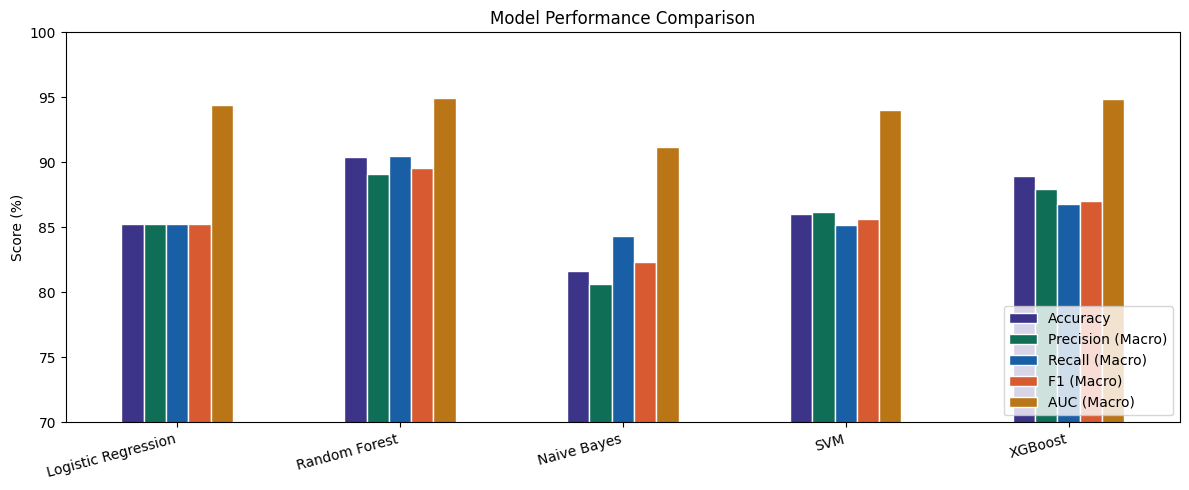

In [44]:

COLORS = ['#3C3489', '#0F6E56', '#185FA5', '#D85A30', '#BA7517']

metrics = ['Accuracy', 'Precision (Macro)', 'Recall (Macro)', 'F1 (Macro)', 'AUC (Macro)']

results_df[metrics].plot(kind='bar', figsize=(12, 5), 
                          color=COLORS, edgecolor='white')
plt.title('Model Performance Comparison')
plt.ylabel('Score (%)')
plt.xlabel('')
plt.xticks(rotation=15, ha='right')
plt.legend(loc='lower right')
plt.ylim(70, 100)
plt.tight_layout()
plt.show()

### Confusion Matrix

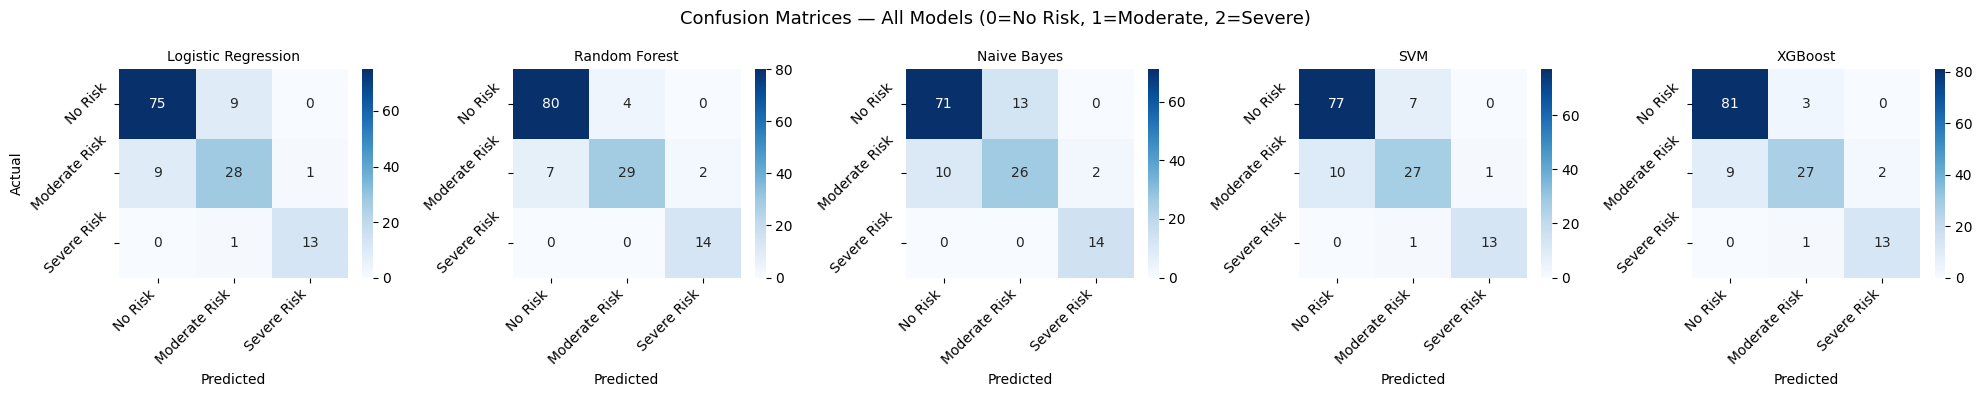

In [47]:
fig, axes = plt.subplots(1, len(models), figsize=(20, 4))

for i, (name, model) in enumerate(models.items()):
    y_pred = model.predict(X_test)
    cm = confusion_matrix(y_test, y_pred, labels=[0, 1, 2])  
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['No Risk', 'Moderate Risk', 'Severe Risk'],
                yticklabels=['No Risk', 'Moderate Risk', 'Severe Risk'],
                ax=axes[i])
    axes[i].set_title(name, fontsize=10)
    axes[i].set_xlabel('Predicted')
    axes[i].set_ylabel('Actual' if i == 0 else '')
    axes[i].set_xticklabels(axes[i].get_xticklabels(), rotation=45, ha='right')
    axes[i].set_yticklabels(axes[i].get_yticklabels(), rotation=45)

plt.suptitle('Confusion Matrices — All Models (0=No Risk, 1=Moderate, 2=Severe)', fontsize=13)
plt.tight_layout()
plt.show()

### K-Fold Cross Validation

In [49]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_results = []

for name, model in models.items():
    scores = cross_val_score(model, X_train, y_train, 
                             cv=cv, scoring='f1_macro')
    cv_results.append({
        'Model': name,
        'CV Mean F1': round(scores.mean() * 100, 2),
        'CV Std':     round(scores.std() * 100, 2)
    })

cv_df = pd.DataFrame(cv_results).set_index('Model')
cv_df

,CV Mean F1,CV Std
Model,,
Logistic Regression,76.08,5.06
Random Forest,76.55,6.91
Naive Bayes,72.01,6.94
SVM,73.37,6.47
XGBoost,76.24,6.97


In [52]:
best_model_name = results_df['F1 (Macro)'].idxmax()
best_model = models[best_model_name]

print(f'Best Model: {best_model_name}')
print(f'\nClassification Report:')
print(classification_report(y_test, best_model.predict(X_test), 
                            target_names=['No Risk', 'Moderate Risk', 'Severe Risk']))

Best Model: Random Forest

Classification Report:
               precision    recall  f1-score   support

      No Risk       0.92      0.95      0.94        84
Moderate Risk       0.88      0.76      0.82        38
  Severe Risk       0.88      1.00      0.93        14

     accuracy                           0.90       136
    macro avg       0.89      0.91      0.90       136
 weighted avg       0.90      0.90      0.90       136



### Feature Importance

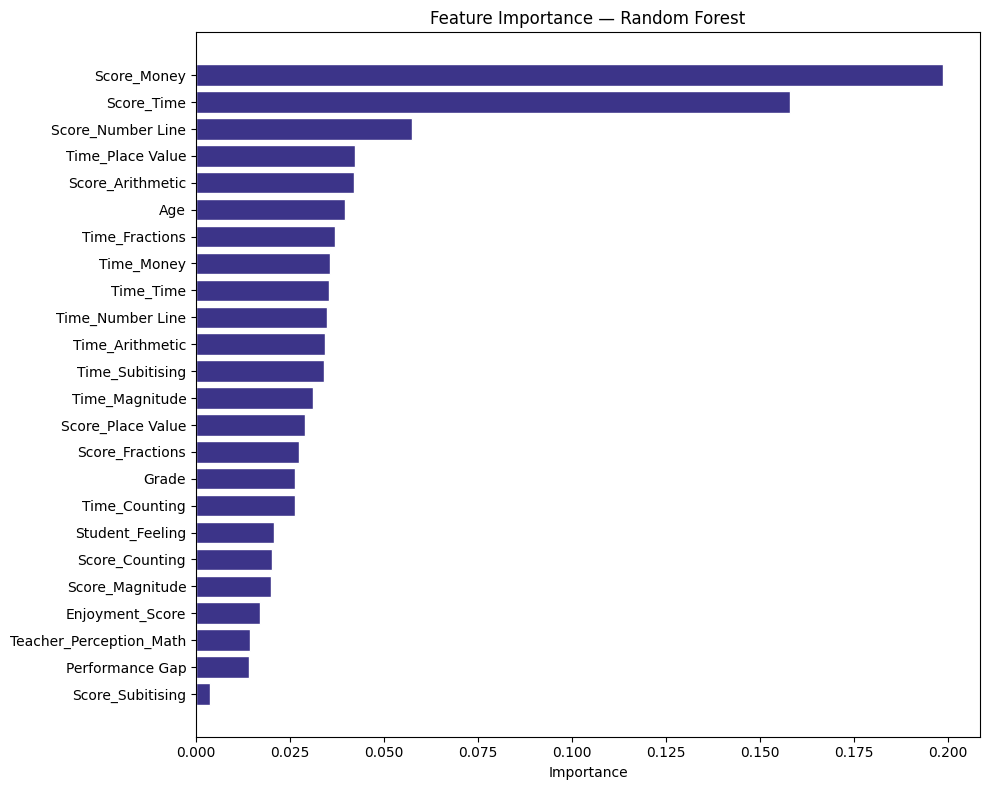

In [53]:
if hasattr(best_model, 'feature_importances_'):
    importance_df = pd.DataFrame({
        'Feature': X_train.columns,
        'Importance': best_model.feature_importances_
    }).sort_values('Importance', ascending=True)

    plt.figure(figsize=(10, 8))
    plt.barh(importance_df['Feature'], importance_df['Importance'],
             color=COLORS[0], edgecolor='white')
    plt.title(f'Feature Importance — {best_model_name}')
    plt.xlabel('Importance')
    plt.tight_layout()
    plt.show()

elif hasattr(best_model, 'coef_'):
    importance_df = pd.DataFrame({
        'Feature': X_train.columns,
        'Importance': abs(best_model.coef_[0])
    }).sort_values('Importance', ascending=True)

    plt.figure(figsize=(10, 8))
    plt.barh(importance_df['Feature'], importance_df['Importance'],
             color=COLORS[0], edgecolor='white')
    plt.title(f'Feature Importance — {best_model_name}')
    plt.xlabel('Coefficient Magnitude')
    plt.tight_layout()
    plt.show()

In [64]:
importance_df = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': models['Random Forest'].feature_importances_
}).sort_values('Importance', ascending=False)

print(importance_df.head(10))

              Feature  Importance
19        Score_Money    0.198546
21         Score_Time    0.157977
13  Score_Number Line    0.057381
12   Time_Place Value    0.042410
15   Score_Arithmetic    0.041992
0                 Age    0.039603
18     Time_Fractions    0.037077
20         Time_Money    0.035604
22          Time_Time    0.035315
14   Time_Number Line    0.034889


### Ablation Study

In [62]:
model = best_model

feature_sets = {
    'Math Scores Only': [col for col in X_train.columns 
                         if col.startswith('Score_')],
    
    'Math Scores + Time': [col for col in X_train.columns 
                            if col.startswith('Score_') 
                            or col.startswith('Time_')],
    
    'Math Scores + Demographics': [col for col in X_train.columns 
                                    if col.startswith('Score_') 
                                    or col in ['Age', 'Grade']],
    
    
    'Math Scores + Academic': [col for col in X_train.columns 
                                if col.startswith('Score_') 
                                or col in ['Performance Gap',
                                           'Teacher_Perception_Math']],

    'Math Scores + Student Feedback': [col for col in X_train.columns 
                                        if col.startswith('Score_') 
                                        or col in ['Student_Feeling', 
                                                   'Enjoyment_Score']],
    
    'Without Time': [col for col in X_train.columns 
                     if not col.startswith('Time_')],
    
    
    'Without Academic': [col for col in X_train.columns 
                         if col not in ['Performance Gap',
                                        'Teacher_Perception_Math']],

    'Full Feature Set': list(X_train.columns)

}

ablation_results = []

for set_name, features in feature_sets.items():
    model.fit(X_train[features], y_train)
    y_pred = model.predict(X_test[features])
    y_prob = model.predict_proba(X_test[features])
    y_test_bin = label_binarize(y_test, classes=[0, 1, 2])
    
    ablation_results.append({
        'Feature Set': set_name,
        'Num Features': len(features),
        'Accuracy':  round(accuracy_score(y_test, y_pred) * 100, 2),
        'Precision': round(precision_score(y_test, y_pred, average='macro', zero_division=0) * 100, 2),
        'Recall':    round(recall_score(y_test, y_pred, average='macro', zero_division=0) * 100, 2),
        'F1 Score':  round(f1_score(y_test, y_pred, average='macro', zero_division=0) * 100, 2),
        'AUC-ROC':   round(roc_auc_score(y_test_bin, y_prob, multi_class='ovr', average='macro') * 100, 2)
    })
    

ablation_df = pd.DataFrame(ablation_results)

ablation_df.head(20)

,Feature Set,Num Features,Accuracy,Precision,Recall,F1 Score,AUC-ROC
0,Math Scores Only,9,88.24,85.97,85.90,85.41,95.47
1,Math Scores + Time,18,88.97,87.92,86.78,87.01,95.76
2,Math Scores + Demographics,11,90.44,89.11,90.52,89.53,96.11
3,Math Scores + Academic,11,88.97,89.75,87.26,88.27,95.02
4,Math Scores + Student Feedback,11,90.44,89.61,90.04,89.38,96.41
5,Without Time,15,86.76,85.40,86.07,85.65,94.22
6,Without Academic,22,88.97,90.34,88.28,88.74,94.52
7,Full Feature Set,24,90.44,89.11,90.52,89.53,94.96


### Saving Best Model

In [63]:
with open('../model/model.pkl', 'wb') as f:
    pickle.dump(best_model, f)
